# Visualize filtering dead cells

See if things look real, does the filtering make sense


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Config
USE_GLOBAL_ZSCORE = False
DRY_RUN = False #os.getenv("USER") == "polya"

# --- Device ---
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"User: {os.getenv('USER')} | Device: {device} | DRY_RUN: {DRY_RUN} | Global Z-score: {USE_GLOBAL_ZSCORE}")

User: polya | Device: mps | DRY_RUN: False | Global Z-score: False


# Wrangling data

In [2]:
import numpy as np
import pandas as pd
from notebooks.experiment.preprocessing import load_and_clean, make_windows_sample, DEFAULT_STIM_COLS

df = pd.read_parquet("dataset.parquet")

# Use all features (default), or pick a subset:
# stim_cols = ["u_t", "m_t", "recency"]
erk, stim, metadata = make_windows_sample(df, window_size=40, rng=42)

print(f"Windows: {erk.shape[0]}, Timepoints: {erk.shape[1]}")
print(f"Stim features: {len(DEFAULT_STIM_COLS)} channels — {DEFAULT_STIM_COLS}")
print(f"Stim shape: {stim.shape}")  # expect (n_windows, 9, 40)
print(f"\nSamples per experiment:")
print(metadata["ramp_pattern_name"].value_counts())

Windows: 11443, Timepoints: 40
Stim features: 9 channels — ['u_t', 'm_t', 'recency', 'ewma_fast', 'ewma_slow', 'n_5', 'slope_5', 'burst_pos', 's_cum']
Stim shape: (11443, 9, 40)

Samples per experiment:
ramp_pattern_name
3-2-1minIntervals    6118
Sustained            3659
ramp1                1300
Single                366
Name: count, dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277523 entries, 0 to 277522
Data columns (total 54 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   mean_intensity_C0_nuc             277523 non-null  float64
 1   mean_intensity_C1_nuc             277523 non-null  float64
 2   label                             277523 non-null  uint32 
 3   x                                 277523 non-null  float64
 4   y                                 277523 non-null  float64
 5   area                              277523 non-null  float64
 6   median_intensity_C0_nuc           277523 non-null  float64
 7   median_intensity_C1_nuc           277523 non-null  float64
 8   mean_intensity_C0_ring            277523 non-null  float64
 9   mean_intensity_C1_ring            277523 non-null  float64
 10  median_intensity_C0_ring          277523 non-null  float64
 11  median_intensity_C1_ring          277523 non-null  f

Original cells: 1971
After filtering: 1953
Removed (dead): 18


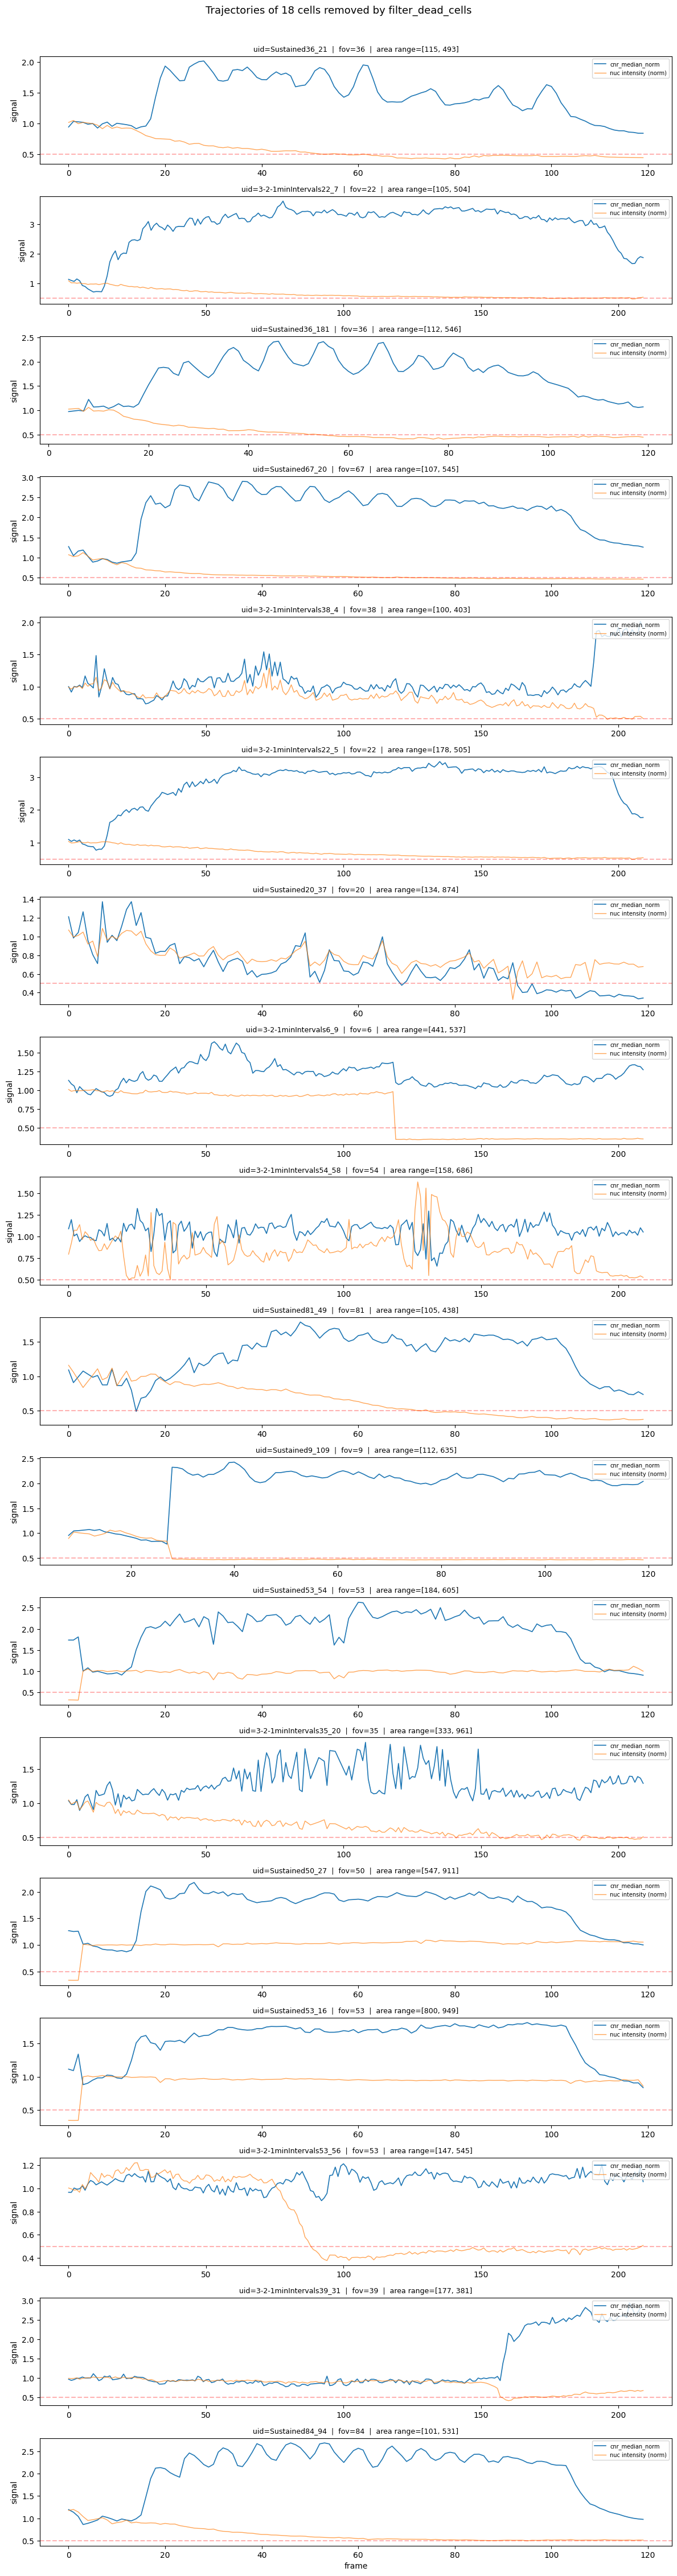

In [17]:
from notebooks.experiment.preprocessing import filter_dead_cells

# Apply filter
DROP_RATIO = 0.5
filtered_df = filter_dead_cells(df, drop_ratio=DROP_RATIO)

# Find UIDs that were removed
removed_uids = set(df["uid"].unique()) - set(filtered_df["uid"].unique())
dead_df = df[df["uid"].isin(removed_uids)].copy()

print(f"Original cells: {df['uid'].nunique()}")
print(f"After filtering: {filtered_df['uid'].nunique()}")
print(f"Removed (dead): {len(removed_uids)}")

# Plot trajectories of removed cells
n_plot = min(20, len(removed_uids))
sample_uids = np.random.choice(list(removed_uids), size=n_plot, replace=False)

fig, axes = plt.subplots(n_plot, 1, figsize=(12, 2.5 * n_plot), sharex=False)
if n_plot == 1:
    axes = [axes]

for ax, uid in zip(axes, sample_uids):
    cell = dead_df[dead_df["uid"] == uid].sort_values("frame")
    ax.plot(cell["frame"], cell["cnr_median_norm"], label="cnr_median_norm", linewidth=1.2)
    ax.plot(cell["frame"], cell["mean_intensity_C0_nuc"] / cell["mean_intensity_C0_nuc"].iloc[:10].median(),
            label="nuc intensity (norm)", linewidth=1, alpha=0.7)
    ax.set_ylabel("signal")
    ax.set_title(f"uid={uid}  |  fov={cell['fov'].iloc[0]}  |  area range=[{cell['area'].min():.0f}, {cell['area'].max():.0f}]",
                 fontsize=9)
    ax.legend(loc="upper right", fontsize=7)
    ax.axhline(DROP_RATIO, color="r", linestyle="--", alpha=0.3, label="drop threshold")

axes[-1].set_xlabel("frame")
fig.suptitle(f"Trajectories of {n_plot} cells removed by filter_dead_cells", fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

# Notes:
Looks correct, will integrate it into the pipeline. It's only 18 cells, so not that much, but maybe useful in the future.